# Motion

A stepper and its ring, a servo and its sag, a sensorless speed loop against the shaft, the loop identified, a propeller.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The stage, armed

`device.gates.on()` arms; the drive on the `model` source turns the stand-in's rotor and its shaft sensor. `Kt = 1.5 P lambda` from the record.

In [3]:
import math
import time

drive = device.drive
drive.configure(source='model')
J, B = 2e-5, 1e-5
drive.model.configure(j=J, b=B, load=0.0)
stage = device.gates.on(bypass_sto=True, ignore_interlock=True)
params = drive.params()
poles = int(params['motor_pole_pairs'])
kt = 1.5 * poles * params['motor_lambda_uvs']
print('armed:', stage['pwm_enabled'])
print('%d pole pairs, lambda %.5f Wb, Kt = 1.5 P lambda = %.4f N.m/A; J %.0e kg.m^2, B %.0e N.m.s'
      % (poles, params['motor_lambda_uvs'], kt, J, B))

armed: True
7 pole pairs, lambda 0.00500 Wb, Kt = 1.5 P lambda = 0.0525 N.m/A; J 2e-05 kg.m^2, B 1e-05 N.m.s


## 3 The stepper: a move and its ring

HOLD drags the rotor on the load-angle spring `amps Kt sin(delta)`: open loop. Ring `sqrt(Kt I P / J)` ~30 Hz, read every 2 ms (20 ms aliased it, 2026-09-07).

In [4]:
def trace(seconds, zero, every=0.002):
    """The shaft every `every` seconds, mechanical degrees from `zero`."""
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        deg = device.angle.state()['degrees']
        rows.append((time.monotonic() - t0, (deg - zero + 180.0) % 360.0 - 180.0))
        time.sleep(every)
    return rows

with device.motion.stepper(amps=2.0, deg_s=90.0) as m:
    detent = device.angle.state()['degrees']
    print('detented: command at %.2f deg, shaft at %.2f' % (m.position, detent))
    m.to(90.0)
    ring = trace(0.6, detent)
    m.step(10)
    print('ten full steps of 1.8 deg: command at %.1f deg' % m.position)
ys = [r[1] for r in ring]
level = sum(ys) / len(ys)
crossings = sum(1 for a, b in zip(ys, ys[1:]) if (a - level) * (b - level) < 0)
ring_hz = crossings / 2.0 / ring[-1][0]
spring_hz = math.sqrt(kt * 2.0 * poles / J) / (2.0 * math.pi)
print('after the 90 deg move: shaft %.2f deg from the detent, ringing %.2f deg '
      'peak to peak at about %.0f Hz; the spring says %.1f Hz'
      % (level, max(ys) - min(ys), ring_hz, spring_hz))
print('%d reads in %.2f s = %.0f Hz' % (len(ring), ring[-1][0], len(ring) / ring[-1][0]))

detented: command at 0.00 deg, shaft at 0.00


ten full steps of 1.8 deg: command at 108.0 deg
after the 90 deg move: shaft 89.96 deg from the detent, ringing 0.44 deg peak to peak at about 30 Hz; the spring says 30.5 Hz
256 reads in 0.60 s = 427 Hz


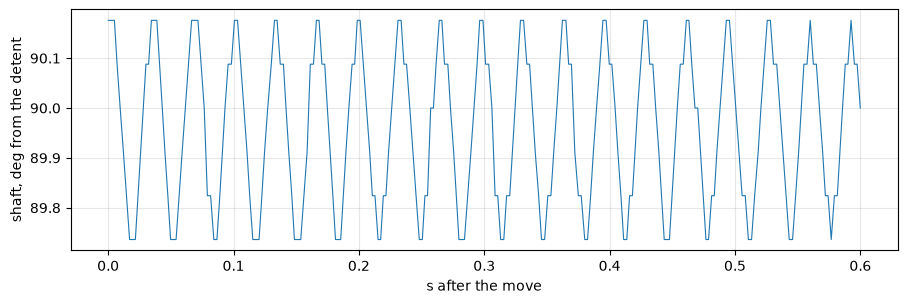

In [5]:
from coaxial.draw.figures import figure, show

fig, (panel,) = figure(rows=1)
panel.plot([r[0] for r in ring], ys, linewidth=0.8)
panel.set_xlabel('s after the move')
panel.set_ylabel('shaft, deg from the detent')
show(fig)

## 4 The servo: sag under load, corrected

The servo: slew, let the ring die, read a mean over it, correct. Sag = `asin(T / I Kt) / P`.

In [6]:
with device.motion.servo(amps=2.0, settle=0.3) as s:
    landed = s.to(45.0, tol=0.5)
    print('no load:   shaft %.2f deg, error %.2f, swing %.2f deg' % (landed, s.error, s.swing))
    first = device.angle.state()['degrees']
    before = trace(0.2, first)
    held = first + sum(r[1] for r in before) / len(before)
    drive.model.configure(load=0.02)
    pulled = trace(1.0, held)
    tail = pulled[len(pulled) // 2:]
    sag = sum(r[1] for r in tail) / len(tail)
    back = s.to(45.0, tol=0.5)
    print('0.02 N.m:  sagged %.2f deg, ringing %.2f deg peak to peak under the load'
          % (sag, max(r[1] for r in tail) - min(r[1] for r in tail)))
    print('corrected: shaft %.2f deg, error %.2f, swing %.2f deg' % (back, s.error, s.swing))
    drive.model.configure(load=0.0)
spring_sag = math.degrees(math.asin(0.02 / (2.0 * kt))) / poles
print('the spring says %.2f deg mechanical: 0.02 N.m against 2.0 A x Kt %.4f = %.3f N.m'
      % (spring_sag, kt, 2.0 * kt))

no load:   shaft 45.00 deg, error 0.00, swing 0.97 deg


0.02 N.m:  sagged -1.58 deg, ringing 2.20 deg peak to peak under the load
corrected: shaft 45.01 deg, error -0.01, swing 1.05 deg
the spring says 1.57 deg mechanical: 0.02 N.m against 2.0 A x Kt 0.0525 = 0.105 N.m


## 5 Sensorless: the observer against the shaft

The observer's electrical angle against the A1335's mechanical one: angles compared at rest, speeds on the way (600 rpm = 3.6 deg/ms). The stage is off after this section.

In [7]:
from coaxial.model.sensorless import RAD_S_PER_RPM

rows = []
last = [None, None]

def watch(v):
    m = drive.model.read()
    shaft = device.angle.state()['degrees']
    now = time.monotonic() - t0
    shaft_rpm = float('nan')
    if last[0] is not None:
        shaft_rpm = ((shaft - last[1] + 90.0) % 360.0 - 90.0) / (now - last[0]) / 6.0
    last[0], last[1] = now, shaft
    bus = v.loop.read()
    rows.append((now, bus['w_ref'] / RAD_S_PER_RPM, m['omega'] / poles / RAD_S_PER_RPM,
                 v.rpm_now, shaft_rpm, math.degrees(m['error']), bus['iq_ref']))

t0 = time.monotonic()
with device.motion.velocity(amps=1.0, hz=3.0) as v:
    v.rpm(600.0, seconds=3.0, watch=watch)
    print('settled at %.0f rpm' % v.rpm_now)
    v.rpm(0.0, seconds=1.5, watch=watch)
    print('stopped at %.0f rpm' % v.rpm_now)
    rotor = math.degrees(drive.model.read()['theta']) / poles
    shaft = device.angle.state()['degrees']
pitch = 360.0 / poles
offset = (shaft - rotor + pitch / 2.0) % pitch - pitch / 2.0
print('%d passes in %.2f s = %.1f Hz' % (len(rows), rows[-1][0], len(rows) / rows[-1][0]))
print('at rest: rotor %.2f deg electrical / %d = %.2f deg; shaft %.2f deg, folded onto '
      'the %.2f deg pole pitch %.2f; %.2f deg apart' % (rotor * poles, poles, rotor, shaft,
                                                         pitch, shaft % pitch, offset))
print('disarmed:', not device.gates.off()['pwm_enabled'])
print('back on the converters:', drive.configure(source='adc')['source'])

settled at 599 rpm


stopped at 1 rpm
111 passes in 4.68 s = 23.7 Hz
at rest: rotor 132.24 deg electrical / 7 = 18.89 deg; shaft 18.81 deg, folded onto the 51.43 deg pole pitch 18.81; -0.08 deg apart
disarmed: True
back on the converters: True


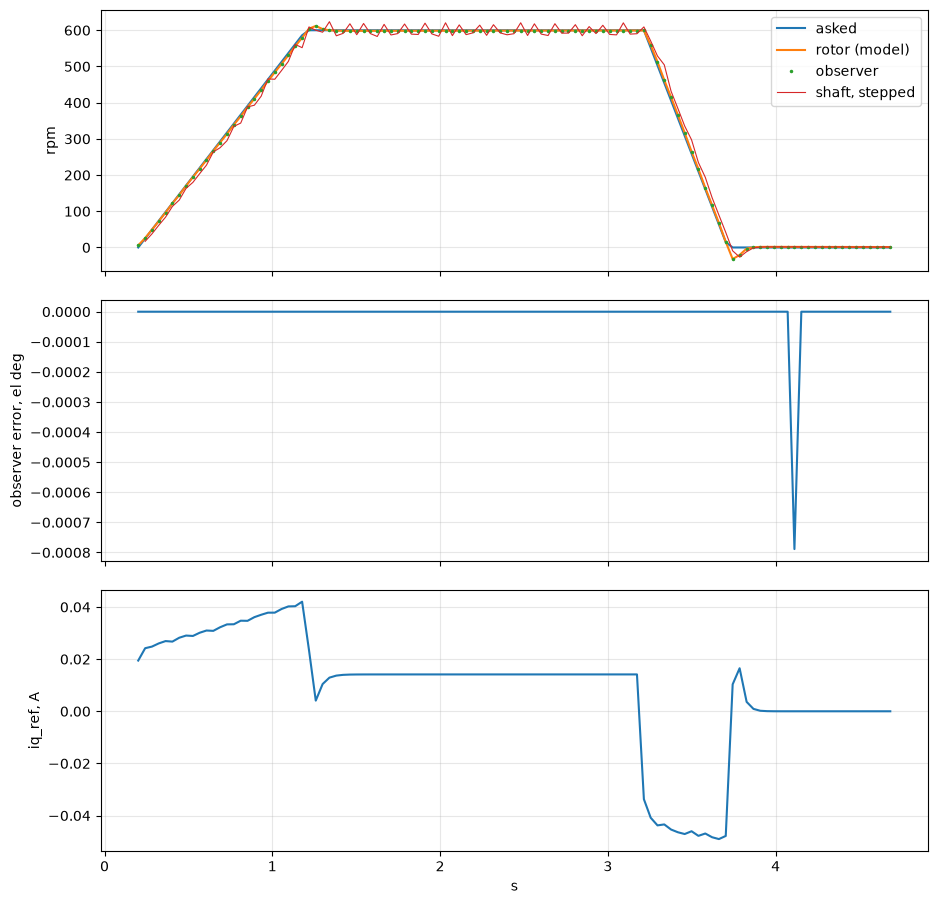

In [8]:
t = [r[0] for r in rows]
fig, (speed, error, current) = figure(rows=3, sharex=True)
speed.plot(t, [r[1] for r in rows], label='asked')
speed.plot(t, [r[2] for r in rows], label='rotor (model)')
speed.plot(t, [r[3] for r in rows], '.', markersize=3, label='observer')
speed.plot(t, [r[4] for r in rows], linewidth=0.8, label='shaft, stepped')
speed.set_ylabel('rpm')
speed.legend(loc='upper right')
error.plot(t, [r[5] for r in rows])
error.set_ylabel('observer error, el deg')
current.plot(t, [r[6] for r in rows])
current.set_ylabel('iq_ref, A')
current.set_xlabel('s')
show(fig)

## 6 The speed loop identified out of its own run

Ramp, d-axis probe, speed loop, current loop, machine on one bus; `identify` returns R, Ld, Lq, lambda, each with its standard error.

In [9]:
from coaxial.control.loop import Ramp, Probe, SpeedLoop, CurrentLoop, Machine, identify
from coaxial.model.motor import BENCH_MOTOR
from coaxial.model import inverter

TWO_PI = 2.0 * math.pi
bench = BENCH_MOTOR
print(bench)
vdc = 24.0
chain = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> Probe(amps=1.0, hz=40.0)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=bench)
         >> CurrentLoop(hz=1000.0, motor=bench, vdc=vdc)
         >> Machine(bench, vdc=vdc, noise=0.02, sub=4))
run = chain.run(seconds=1.4, dt=2.0 * inverter.TS)
print('samples %d at %.0f us; top %.0f rad/s mechanical'
      % (len(run['t']), 2e6 * inverter.TS, run['w'].max()))

<stand-in bench motor ESTIMATED: R 0.0500 ohm, Ld 20.0 uH, Lq 30.0 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>


samples 35000 at 40 us; top 397 rad/s mechanical


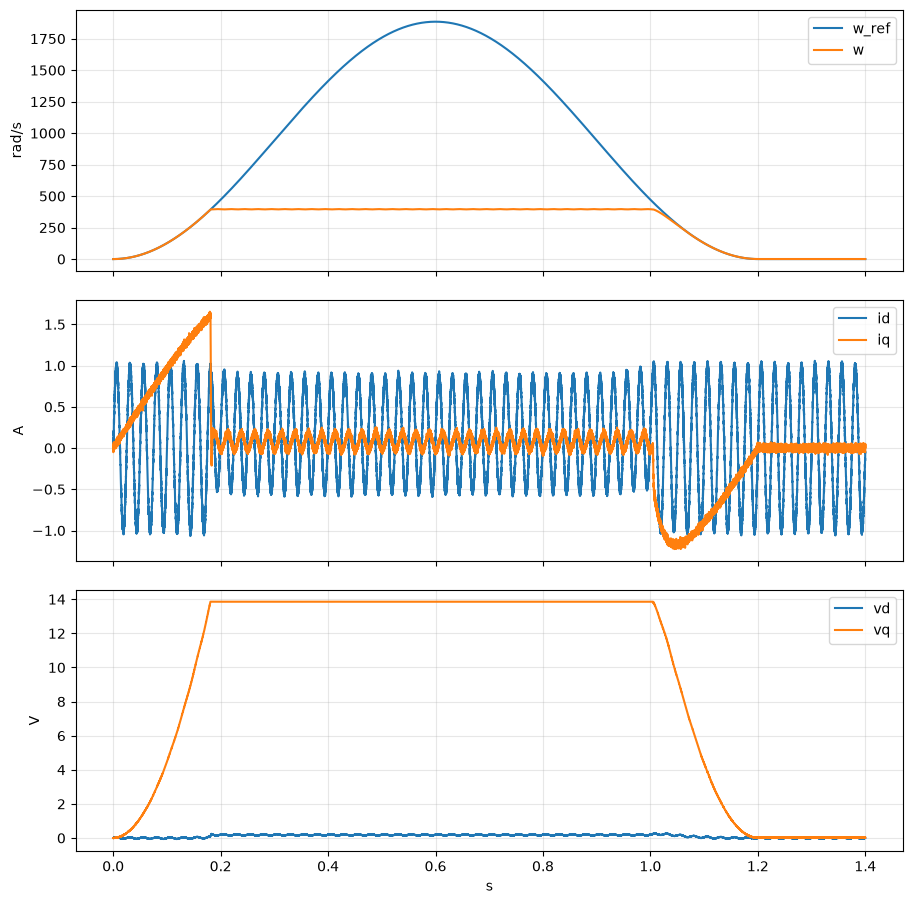

In [10]:
fig, (speed, current, voltage) = figure(rows=3, sharex=True)
speed.plot(run['t'], run['w_ref'], label='w_ref')
speed.plot(run['t'], run['w'], label='w')
speed.set_ylabel('rad/s')
speed.legend()
current.plot(run['t'], run['id'], label='id')
current.plot(run['t'], run['iq'], label='iq')
current.set_ylabel('A')
current.legend()
voltage.plot(run['t'], run['vd'], label='vd')
voltage.plot(run['t'], run['vq'], label='vq')
voltage.set_ylabel('V')
voltage.set_xlabel('s')
voltage.legend()
show(fig)

In [11]:
fit, got = identify(run, bench.poles)
print(fit)
print(fit.source)
print('condition %.2e  residual %.4f V' % (got['condition'], got['residual_v']))
TRUTH = (('r', bench.r), ('ld', bench.ld), ('lq', bench.lq), ('lam', bench.lam))
for name, truth in TRUTH:
    print('%-4s truth %.5g  fit %.5g  %+.1f %%  uncertainty %.1f %%  trusted %s'
          % (name, truth, got[name], 100.0 * (got[name] / truth - 1.0),
             100.0 * got['uncertainty'][name], got['trusted'][name]))

<identified ESTIMATED: R 0.0816 ohm, Ld 18.7 uH, Lq -2.7 uH, lambda 0.00500 Wb, 7 pole pairs, KV 158>
least squares over a simulated run - 35000 samples, condition 7.5e-01
condition 7.48e-01  residual 0.0990 V
r    truth 0.05  fit 0.08163  +63.3 %  uncertainty 0.8 %  trusted True
ld   truth 2e-05  fit 1.8732e-05  -6.3 %  uncertainty 2.3 %  trusted True
lq   truth 3e-05  fit -2.6631e-06  -108.9 %  uncertainty 21.4 %  trusted False
lam  truth 0.005  fit 0.004996  -0.1 %  uncertainty 0.0 %  trusted True


Without the probe: `did/dt` unexcited.

In [12]:
still = (Ramp(top=300.0 * TWO_PI, rise=0.6)
         >> SpeedLoop(hz=8.0, limit=6.0, motor=bench)
         >> CurrentLoop(hz=1000.0, motor=bench, vdc=vdc)
         >> Machine(bench, vdc=vdc, noise=0.02, sub=4))
run2 = still.run(seconds=1.4, dt=2.0 * inverter.TS)
_, got2 = identify(run2, bench.poles)
for name, truth in TRUTH:
    print('%-4s fit %.5g  %+.1f %%  uncertainty %.1f %%  trusted %s'
          % (name, got2[name], 100.0 * (got2[name] / truth - 1.0),
             100.0 * got2['uncertainty'][name], got2['trusted'][name]))

r    fit 0.0046473  -90.7 %  uncertainty 24.1 %  trusted False
ld   fit 5.2515e-06  -73.7 %  uncertainty 24.4 %  trusted False
lq   fit -3.3285e-06  -111.1 %  uncertainty 17.4 %  trusted False
lam  fit 0.004997  -0.1 %  uncertainty 0.0 %  trusted True


## 7 The 5230SL and its propeller against the stand

`coaxial.model.motor`: the 5230SL 190KV from the sheet, R/Ld/Lq/J from the size class; the APC20x10E fitted over the stand's 22 rows at 37 V; up to 6717 rpm and back.

In [13]:
from coaxial.model.motor import PLATINUM_5230SL, APC20x10E, APC20X10E_CURVE, RATINGS, KT_NM_PER_AMP

motor = PLATINUM_5230SL
print(motor)
print(motor.source)
print(APC20x10E, '-', APC20x10E.source)
print({k: RATINGS[k] for k in ('slots_poles', 'kv', 'i_max', 'p_max', 'source')})
print('Kt %.4f N.m/A' % KT_NM_PER_AMP)

<Hobbywing Platinum 5230SL 190KV ESTIMATED: R 0.0300 ohm, Ld 22.0 uH, Lq 29.0 uH, lambda 0.00207 Wb, 14 pole pairs, KV 190>
poles and friction from the manufacturer sheet (see RATINGS); R, Ld, Lq and J estimated from the size class - replace with an identification against the real machine
<APC20x10E: 5.143e-06 N.m/(rad/s)^2> - least squares over the 190KV sheet, 37 V, 25 C, sea level
{'slots_poles': '24N28P', 'kv': 190.0, 'i_max': 112.5, 'p_max': 4985.0, 'source': 'hobbywing.com Platinum 5220/5230 specification page'}
Kt 0.0435 N.m/A


In [14]:
import numpy as np

top = 6717.0 * TWO_PI / 60.0
sweep = (Ramp(top, rise=2.0)
         >> SpeedLoop(hz=4.0, limit=RATINGS['i_max'], motor=motor, load=APC20x10E)
         >> CurrentLoop(hz=800.0, motor=motor, vdc=37.0)
         >> Machine(motor, vdc=37.0, load=APC20x10E, noise=0.0, sub=4))
prop = sweep.run(seconds=4.5, dt=4.0 * inverter.TS, every=25)
rpm = prop['w'] * 60.0 / TWO_PI
torque = APC20x10E.k * prop['w'] ** 2
electrical = 1.5 * (prop['vd'] * prop['id'] + prop['vq'] * prop['iq'])
peak = int(rpm.argmax())
w_e = prop['w_e'][peak]
print('reached %.0f rpm, iq peak %.1f A, v_sat %.0f %% of the run'
      % (rpm.max(), abs(prop['iq']).max(), 100.0 * prop['v_sat'].mean()))
print('at the top: back-EMF %.1f V, omega Lq iq %.1f V, |v| %.1f of the %.1f V a sine gets from 37 V'
      % (w_e * motor.lam, w_e * motor.lq * prop['iq'][peak],
         math.hypot(prop['vd'][peak], prop['vq'][peak]), 37.0 / math.sqrt(3.0)))

reached 5696 rpm, iq peak 46.5 A, v_sat 22 % of the run
at the top: back-EMF 17.3 V, omega Lq iq 11.1 V, |v| 21.3 of the 21.4 V a sine gets from 37 V


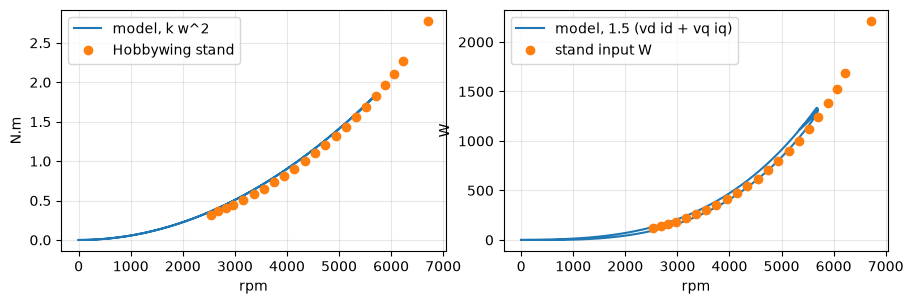

In [15]:
stand = np.array(APC20X10E_CURVE)
fig, (shaft, power) = figure(rows=1, cols=2)
shaft.plot(rpm, torque, label='model, k w^2')
shaft.plot(stand[:, 0], stand[:, 1], 'o', label='Hobbywing stand')
shaft.set_xlabel('rpm')
shaft.set_ylabel('N.m')
shaft.legend()
power.plot(rpm, electrical, label='model, 1.5 (vd id + vq iq)')
power.plot(stand[:, 0], stand[:, 2], 'o', label='stand input W')
power.set_xlabel('rpm')
power.set_ylabel('W')
power.legend()
show(fig)

In [16]:
print(' rpm    stand N.m   model N.m   stand W   model W')
for row_rpm, row_torque, row_watts in APC20X10E_CURVE[::4]:
    w = row_rpm * TWO_PI / 60.0
    near = np.argmin(np.abs(rpm[:peak] - row_rpm))
    print('%5d   %8.2f   %8.2f   %8.0f   %8.0f'
          % (row_rpm, row_torque, APC20x10E.k * w * w, row_watts, electrical[near]))
worst = 0.0
for row_rpm, row_torque, _watts in APC20X10E_CURVE:
    w = row_rpm * TWO_PI / 60.0
    worst = max(worst, abs(APC20x10E.k * w * w / row_torque - 1.0))
print('fit: k %.3e N.m/(rad/s)^2, worst row %.1f %% off a pure square' % (APC20x10E.k, 100.0 * worst))

 rpm    stand N.m   model N.m   stand W   model W
 2534       0.32       0.36        125        131
 3163       0.51       0.56        219        243
 3946       0.81       0.88        411        452
 4740       1.20       1.27        704        778
 5518       1.69       1.72       1118       1198
 6226       2.27       2.19       1684       1321
fit: k 5.143e-06 N.m/(rad/s)^2, worst row 13.2 % off a pure square


In [17]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 8 Results

In [18]:
errs = [abs(r[5]) for r in rows]
rms = math.sqrt(sum(e * e for e in errs) / len(errs))
settled = [r for r in rows if abs(r[1] - 600.0) < 1.0 and r[4] == r[4]]
tach = [r[3] - r[4] for r in settled]
top_rpm = max(r[2] for r in rows)
top_row = APC20X10E_CURVE[-1]
print('1. stepper     ring %.2f deg peak to peak at about %.0f Hz after a 90 deg move, the spring says %.1f Hz;'
      % (max(ys) - min(ys), ring_hz, spring_hz))
print('               shaft %.2f deg from the detent against a command of 90.0; read at %.0f Hz'
      % (level, len(ring) / ring[-1][0]))
print('2. servo       no load: shaft %.2f deg, error %.2f; 0.02 N.m: sag %.2f deg measured, %.2f by the spring'
      % (landed, 45.0 - landed, sag, spring_sag))
print('               corrected: shaft %.2f deg, error %.2f, swing %.2f deg; holding torque 2.0 A x Kt %.4f = %.3f N.m'
      % (back, 45.0 - back, s.swing, kt, 2.0 * kt))
print('3. sensorless  %d passes at %.1f Hz; top %.0f rpm mechanical = %.0f rad/s electrical at %d pole pairs'
      % (len(rows), len(rows) / rows[-1][0], top_rpm, top_rpm * RAD_S_PER_RPM * poles, poles))
print('               observer error %.3f deg electrical rms, worst %.3f = %.4f deg mechanical; zero at constant speed'
      % (rms, max(errs), max(errs) / poles))
print('               observer minus shaft speed, settled: %+.1f rpm mean, %.1f rms over %d passes; at rest %.2f deg apart on the pole pitch'
      % (sum(tach) / len(tach), math.sqrt(sum(x * x for x in tach) / len(tach)), len(tach), offset))
print('4. identified  %-6s %-10s %-10s %-10s %s' % ('', 'truth', 'probe', 'no probe', 'probe -> none'))
for name, truth in TRUTH:
    print('               %-6s %-10.5g %-10.5g %-10.5g %+.1f %% -> %+.1f %%'
          % (name, truth, got[name], got2[name],
             100.0 * (got[name] / truth - 1.0), 100.0 * (got2[name] / truth - 1.0)))
print('               trusted with the probe %s, without %s; condition %.2e and %.2e'
      % ([n for n, _ in TRUTH if got['trusted'][n]], [n for n, _ in TRUTH if got2['trusted'][n]],
         got['condition'], got2['condition']))
print('5. propeller   k %.3e N.m/(rad/s)^2, worst row %.1f %% off a square; at %d rpm %.2f N.m needs %.1f A at Kt %.4f'
      % (APC20x10E.k, 100.0 * worst, top_row[0], top_row[1], top_row[1] / KT_NM_PER_AMP, KT_NM_PER_AMP))
print('               the model reached %.0f rpm at 37 V, iq peak %.1f A, v_sat %.0f %% of the run; the board %.0f A rated, the motor %.1f A burst'
      % (rpm.max(), abs(prop['iq']).max(), 100.0 * prop['v_sat'].mean(), 100.0, RATINGS['i_max']))
print('               lambda %.5f Wb from %d KV at %d pole pairs; Kt = 1.5 P lambda = %.4f N.m/A'
      % (motor.lam, RATINGS['kv'], motor.poles, 1.5 * motor.poles * motor.lam))

1. stepper     ring 0.44 deg peak to peak at about 30 Hz after a 90 deg move, the spring says 30.5 Hz;
               shaft 89.96 deg from the detent against a command of 90.0; read at 427 Hz
2. servo       no load: shaft 45.00 deg, error 0.00; 0.02 N.m: sag -1.58 deg measured, 1.57 by the spring
               corrected: shaft 45.01 deg, error -0.01, swing 1.05 deg; holding torque 2.0 A x Kt 0.0525 = 0.105 N.m
3. sensorless  111 passes at 23.7 Hz; top 612 rpm mechanical = 449 rad/s electrical at 7 pole pairs
               observer error 0.000 deg electrical rms, worst 0.001 = 0.0001 deg mechanical; zero at constant speed
               observer minus shaft speed, settled: -0.1 rpm mean, 13.9 rms over 50 passes; at rest -0.08 deg apart on the pole pitch
4. identified         truth      probe      no probe   probe -> none
               r      0.05       0.08163    0.0046473  +63.3 % -> -90.7 %
               ld     2e-05      1.8732e-05 5.2515e-06 -6.3 % -> -73.7 %
               lq  

- The servo corrects once per move: per pass it pumps its ring (FINDINGS 2026-09-07).
- With the probe R, Ld, lambda are trusted, R 63 % high (the discretisation); Lq not. Without it, lambda alone.
- `j` 5x the plant: +900 rpm asked, -1552 delivered (FINDINGS).
- Out of voltage short of 6717 rpm: Lq drops 11 of 21.4 V at 46 A.
- 100 A inverter before 112.5 A motor.

**Bench.** The ring against `sqrt(Kt I P / J)` gives the real J. The servo needs a magnet, velocity a commissioned record.

## References

* `host/coaxial/control/motion.py` - the three verbs: the slew, the soft energize, the ring-aware measurement, the fault read a pass
* `host/coaxial/control/loop.py` - the blocks on one bus: ramp, probe, speed loop, current loop, machine, and `identify`
* `host/coaxial/model/sysid.py` - the least squares behind `identify`: two equations a sample, an error bar per column
* `host/coaxial/model/motor.py` - the 5230SL as the sheet gives it, the propeller and its 22-row curve, `Kt = 1.5 P lambda`
* `host/coaxial/simulated/drive/` - the stand-in's rotor, the spring under HOLD, and the PLL lag that stands in for the observer
* `host/tests/test_sensorless.py` - the verbs pinned on the stand-in, the dangerous paths included: a load past the holding torque, a trip mid-spin
* `host/tools/sim/observer_run.py` - the firmware's own observer, run on the host, and the crossover it computes
* `docs/FINDINGS.md` - the motion verbs, 2026-09-07: the aliased ring, the pumped corrections, the rotor's integrator